# Foreign Exchange Volatility and Trend Analysis

## Introduction

This notebook presents a comprehensive quantitative analysis of foreign exchange rate data with the objective of identifying market trends and estimating risk metrics. The analysis encompasses the collection, processing, and statistical examination of historical daily exchange rates for multiple major currency pairs.

## Research Objectives

The primary objectives of this study are:

1. To collect and process historical daily foreign exchange rate data for multiple currency pairs
2. To compute quantitative risk metrics including volatility measures and technical indicators
3. To analyze price trends through moving average techniques
4. To evaluate momentum characteristics using established technical indicators
5. To visualize the analytical results through comprehensive graphical representations

## Currency Pairs Under Study

The analysis focuses on three major currency pairs:

- **EUR/USD**: Euro to US Dollar exchange rate
- **GBP/USD**: British Pound to US Dollar exchange rate
- **USD/JPY**: US Dollar to Japanese Yen exchange rate

## Data Coverage

- **Analysis Period**: January 1, 2022 to December 31, 2024
- **Temporal Resolution**: Daily observations
- **Total Duration**: 3 years of historical data

## Technical Indicators

The following quantitative indicators are computed:

1. **Daily Returns**: Percentage change in closing prices between consecutive trading days
2. **Rolling Volatility**: Annualized standard deviation of returns over 30-day and 90-day rolling windows
3. **Simple Moving Averages**: 20-day and 50-day moving averages of closing prices
4. **Relative Strength Index**: 14-period momentum oscillator

## Methodology

The analytical workflow consists of the following sequential steps:

1. **Data Acquisition**: Retrieval of historical OHLC (Open, High, Low, Close) data from Yahoo Finance API
2. **Data Preprocessing**: Alignment of time series and imputation of missing values using sequential 5-day rolling mean methodology
3. **Data Integration**: Consolidation of multiple currency pair datasets into a unified structure
4. **Data Export**: Generation of processed dataset in CSV format for further analysis
5. **Statistical Analysis**: Computation of returns, volatility measures, moving averages, and momentum indicators
6. **Visualization**: Creation of analytical dashboards presenting key metrics and trends

---



In [1]:
import pandas as pd        # Data manipulation
import numpy as np
import matplotlib.pyplot as plt  # Plotting
import yfinance as yf      # Download financial data

# Set plot style
plt.style.use("seaborn-v0_8")

## 1. Data Collection

This section describes the data acquisition process for the foreign exchange rate analysis. Historical daily exchange rate data is retrieved from the Yahoo Finance API for three major currency pairs: EUR/USD, GBP/USD, and USD/JPY.

For each currency pair, the dataset contains daily OHLC (Open, High, Low, Close) price data covering the period from January 1, 2022 to December 31, 2024. The data structure for each observation includes:

- **Open**: The opening exchange rate for the trading day
- **High**: The maximum exchange rate observed during the trading day
- **Low**: The minimum exchange rate observed during the trading day
- **Close**: The closing exchange rate for the trading day

These price components are essential for computing daily returns, volatility measures, and other technical indicators used in the subsequent analysis.



In [2]:
# Define the tickers and their Yahoo Finance symbols
tickers = {"EURUSD": "EURUSD=X", "GBPUSD": "GBPUSD=X", "USDJPY": "JPY=X"}
start_date = "2022-01-01"
end_date = "2024-12-31"

print(f"Downloading FX data from {start_date} to {end_date}...")
data = {}

# Download the daily OHLC data for each FX pair
for name, ticker in tickers.items():
    df = yf.download(
        ticker, 
        start=start_date, 
        end=end_date, 
        progress=False, 
        interval="1d", 
        auto_adjust=False, 
        multi_level_index=False
    )
    df = df.reset_index()[["Date", "Open", "High", "Low", "Close"]]  # Keep relevant columns
    df = df.sort_values("Date").set_index("Date")  # Ensure sorted by date and 'Date' is index
    data[name] = df
    print(f"{name}: {len(df)} rows, {df.index.min()} to {df.index.max()}")  # Quick info

print(f"\nData preview (EURUSD):")
display(data["EURUSD"].head())  # Show first few rows of EURUSD data


EURUSD: 781 rows, 2022-01-03 00:00:00 to 2024-12-30 00:00:00
GBPUSD: 781 rows, 2022-01-03 00:00:00 to 2024-12-30 00:00:00
USDJPY: 781 rows, 2022-01-03 00:00:00 to 2024-12-30 00:00:00

Data preview (EURUSD):


,Open,High,Low,Close
Date,,,,
2022-01-03,1.137385,1.137592,1.128541,1.137346
2022-01-04,1.130199,1.132300,1.127345,1.130224
2022-01-05,1.128541,1.134559,1.127764,1.128363
2022-01-06,1.131222,1.133067,1.128554,1.131350
2022-01-07,1.129586,1.135976,1.129050,1.129688


## 2. Data Preprocessing and Alignment

Foreign exchange markets operate on a five-day trading week, resulting in missing observations for weekends and holidays in the raw dataset. To facilitate comparative analysis across currency pairs and ensure temporal consistency, all time series are aligned to a complete calendar framework.

### Imputation Methodology: Sequential 5-Day Rolling Mean

Missing values are imputed using a sequential rolling mean approach. For each missing observation at time $t$, the imputed value is calculated as the arithmetic mean of the five preceding trading days:

$$\text{Value}_t = \frac{1}{5} \sum_{i=1}^{5} \text{Value}_{t-i}$$

where $\text{Value}_{t-i}$ denotes the observed or previously imputed value from $i$ days prior to time $t$. This methodology is applied sequentially, such that previously imputed values are incorporated into subsequent calculations.

### Methodological Rationale

This imputation approach offers several advantages over alternative methods:

1. **Trend Preservation**: The rolling mean methodology better preserves underlying trend characteristics compared to simple forward-fill techniques
2. **Smooth Transitions**: The method generates smooth interpolations between trading days, avoiding artificial price plateaus
3. **Data-Driven**: The imputation relies on actual market observations rather than static values, maintaining the statistical properties of the time series



In [3]:
# Generate a full daily date range based on EURUSD data
full_range = pd.date_range(start=data["EURUSD"].index.min(), end=data["EURUSD"].index.max(), freq="D")

# Align all DataFrames to the full range, using sequential 5-day rolling mean for missing days
aligned = {}
for name, df in data.items():
    df_aligned = df.reindex(full_range)
    
    # Process each date sequentially
    for idx in df_aligned.index:
        # Check if there are missing values for this date
        if df_aligned.loc[idx].isna().any():
            # For each missing column, calculate the mean of the previous 5 days
            for col in df_aligned.columns:
                if pd.isna(df_aligned.loc[idx, col]):
                    # Take the previous 5 days (may include already calculated values)
                    prev_values = df_aligned.loc[:idx, col].iloc[:-1].tail(5)
                    mean_value = prev_values.mean()
                    if not pd.isna(mean_value):
                        df_aligned.loc[idx, col] = mean_value
                    else:
                        # Fallback: forward-fill if not enough values
                        df_aligned.loc[idx, col] = df_aligned.loc[:idx, col].iloc[:-1].iloc[-1]
    
    aligned[name] = df_aligned

print(f"Aligned to full calendar: {len(full_range)} days")
for name, df in aligned.items():
    # Check row count and missing values for each pair
    print(f"  {name}: {len(df)} rows, missing values: {df.isna().sum().sum()}")


Aligned to full calendar: 1093 days
  EURUSD: 1093 rows, missing values: 0
  GBPUSD: 1093 rows, missing values: 0
  USDJPY: 1093 rows, missing values: 0


In [4]:
# Merge all FX pairs (OHLC) into one DataFrame
merged = pd.DataFrame(index=full_range)

# Loop over each currency pair and each OHLC column
for name in ["EURUSD", "GBPUSD", "USDJPY"]:
    for col in ["Open", "High", "Low", "Close"]:
        # Add the corresponding column to the merged DataFrame
        merged[f"{name}_{col}"] = aligned[name][col]

# Print info about the merged dataset
print(f"Merged dataset: {len(merged)} rows, {len(merged.columns)} columns")
print(f"\nColumns: {list(merged.columns)}")
print(f"\nMerged data preview:")
display(merged.head())


Merged dataset: 1093 rows, 12 columns

Columns: ['EURUSD_Open', 'EURUSD_High', 'EURUSD_Low', 'EURUSD_Close', 'GBPUSD_Open', 'GBPUSD_High', 'GBPUSD_Low', 'GBPUSD_Close', 'USDJPY_Open', 'USDJPY_High', 'USDJPY_Low', 'USDJPY_Close']

Merged data preview:


,EURUSD_Open,EURUSD_High,EURUSD_Low,EURUSD_Close,GBPUSD_Open,GBPUSD_High,GBPUSD_Low,GBPUSD_Close,USDJPY_Open,USDJPY_High,USDJPY_Low,USDJPY_Close
2022-01-03,1.137385,1.137592,1.128541,1.137346,1.352228,1.353180,1.343274,1.352228,115.136002,115.360001,114.973999,115.141998
2022-01-04,1.130199,1.132300,1.127345,1.130224,1.348279,1.355675,1.346076,1.348327,115.316002,116.339996,115.299004,115.328003
2022-01-05,1.128541,1.134559,1.127764,1.128363,1.353052,1.357331,1.352265,1.353143,116.165001,116.235001,115.626999,116.174004
2022-01-06,1.131222,1.133067,1.128554,1.131350,1.355546,1.355748,1.349109,1.355565,116.128998,116.179001,115.653999,116.127998
2022-01-07,1.129586,1.135976,1.129050,1.129688,1.353400,1.358345,1.352942,1.353363,115.870003,116.029999,115.591003,115.864998


In [5]:
# Export merged data to CSV file
csv_filename = "fx_data_sample.csv"
merged.to_csv(csv_filename)
print(f"Data exported successfully to {csv_filename}")
print(f"File contains {len(merged)} rows and {len(merged.columns)} columns")
print(f"Date range: {merged.index.min()} to {merged.index.max()}")



Data exported successfully to fx_data_sample.csv
File contains 1093 rows and 12 columns
Date range: 2022-01-03 00:00:00 to 2024-12-30 00:00:00


## 3. Daily Returns Calculation

Daily returns represent the percentage change in the closing exchange rate between consecutive trading days. This metric serves as the fundamental building block for subsequent volatility calculations and risk assessments.

### Mathematical Formulation

For a currency pair at time $t$, the daily return $R_t$ is computed as:

$$R_t = \frac{P_t - P_{t-1}}{P_{t-1}} \times 100\%$$

where:
- $P_t$ denotes the closing exchange rate at time $t$
- $P_{t-1}$ denotes the closing exchange rate at time $t-1$

The percentage representation facilitates cross-pair comparisons by normalizing price movements relative to the initial price level, thereby enabling meaningful statistical analysis across currency pairs with different absolute price levels.

### Economic Interpretation

- **Positive returns** ($R_t > 0$): Indicate appreciation of the base currency relative to the quote currency
- **Negative returns** ($R_t < 0$): Indicate depreciation of the base currency relative to the quote currency
- **Zero returns** ($R_t = 0$): Indicate no change in the exchange rate

Daily returns constitute the primary input for volatility estimation and serve as the basis for various risk metrics in financial analysis.



In [6]:
# Calculate daily returns (percentage) for each currency pair
returns_pct = pd.DataFrame(index=merged.index)
for name in ["EURUSD", "GBPUSD", "USDJPY"]:
    returns_pct[f"{name}_Return"] = merged[f"{name}_Close"].pct_change() * 100

# Drop NaN rows and display results in percentage form
returns_pct = returns_pct.dropna()
print(f"Returns calculated (percentage): {len(returns_pct)} rows")
print("\nReturns table (first 5 rows):")
display(returns_pct.head())

print("\nReturns statistics (percentage):")
display(returns_pct.describe())

# Convert back to decimal form for downstream calculations
returns = returns_pct / 100


Returns calculated (percentage): 1092 rows

Returns table (first 5 rows):


,EURUSD_Return,GBPUSD_Return,USDJPY_Return
2022-01-04,-0.626146,-0.288540,0.161544
2022-01-05,-0.164740,0.357232,0.733560
2022-01-06,0.264733,0.178936,-0.039600
2022-01-07,-0.146863,-0.162409,-0.226475
2022-01-08,0.151015,-0.061907,-0.118757



Returns statistics (percentage):


,EURUSD_Return,GBPUSD_Return,USDJPY_Return
count,1092.000000,1092.000000,1092.000000
mean,-0.006704,-0.004852,0.031252
std,0.496294,0.594885,0.684295
min,-2.342236,-4.783820,-3.887872
25%,-0.248793,-0.282246,-0.262955
50%,-0.003868,0.005520,0.045790
75%,0.252125,0.261692,0.356342
max,2.548688,3.077187,2.549874


## 4. Rolling Volatility Estimation (Annualized)

Volatility quantifies the dispersion of exchange rate returns and serves as a primary risk metric in financial analysis. This section presents the methodology for computing rolling volatility measures.

### Volatility Calculation Methodology

Rolling volatility is computed as the standard deviation of daily returns over a specified rolling window, subsequently annualized to facilitate comparison across different time horizons:

$$\sigma_{\text{annual}} = \sigma_{\text{daily}} \times \sqrt{T}$$

where:
- $\sigma_{\text{daily}}$ represents the standard deviation of daily returns over the rolling window
- $T = 252$ denotes the number of trading days in a standard calendar year
- $\sigma_{\text{annual}}$ represents the annualized volatility measure

### Rolling Window Specifications

Two distinct volatility measures are computed to capture different temporal perspectives:

1. **30-Day Volatility**: Short-term risk assessment
   $$\sigma_{30d}(t) = \text{std}(R_{t-29}, R_{t-28}, \ldots, R_t) \times \sqrt{252}$$

2. **90-Day Volatility**: Medium-term risk assessment
   $$\sigma_{90d}(t) = \text{std}(R_{t-89}, R_{t-88}, \ldots, R_t) \times \sqrt{252}$$

### Economic Significance

- **Elevated volatility**: Indicates increased price dispersion and heightened market uncertainty
- **Reduced volatility**: Suggests relative price stability and lower perceived risk
- **Volatility clustering**: Empirical observation that periods of high volatility tend to persist, consistent with autoregressive conditional heteroskedasticity (ARCH) effects

The annualization factor $\sqrt{252}$ transforms daily volatility estimates to an annualized scale, enabling standardized risk comparisons across different measurement periods and financial instruments.



In [7]:
TRADING_DAYS = 252  # Number of trading days in a year
volatility = pd.DataFrame(index=returns.index)  # DataFrame to store volatilities

for name in ["EURUSD", "GBPUSD", "USDJPY"]:
    ret = returns[f"{name}_Return"]  # Daily returns for the pair
    # 30-day rolling annualized volatility
    volatility[f"{name}_vol_30d"] = ret.rolling(30).std() * np.sqrt(TRADING_DAYS)
    # 90-day rolling annualized volatility
    volatility[f"{name}_vol_90d"] = ret.rolling(90).std() * np.sqrt(TRADING_DAYS)

# Display an example of the last 5 rows of the volatility table
print("\nVolatility table (last 5 rows):")
display(volatility.tail())


print("Volatility calculated (annualized)")
print(f"\nCurrent 30d volatility:")
for name in ["EURUSD", "GBPUSD", "USDJPY"]:
    current_vol = volatility[f"{name}_vol_30d"].iloc[-1]  # Latest 30d volatility
    print(f"  {name}: {current_vol:.2%}")



Volatility table (last 5 rows):


,EURUSD_vol_30d,EURUSD_vol_90d,GBPUSD_vol_30d,GBPUSD_vol_90d,USDJPY_vol_30d,USDJPY_vol_90d
2024-12-26,0.067357,0.071048,0.078530,0.076445,0.126381,0.114814
2024-12-27,0.066333,0.071200,0.077994,0.076283,0.123437,0.114152
2024-12-28,0.062944,0.071193,0.073975,0.076300,0.119102,0.114437
2024-12-29,0.062926,0.071094,0.073765,0.076266,0.118905,0.113171
2024-12-30,0.061682,0.071143,0.072235,0.076561,0.115770,0.112905


Volatility calculated (annualized)

Current 30d volatility:
  EURUSD: 6.17%
  GBPUSD: 7.22%
  USDJPY: 11.58%


## 5. Simple Moving Averages

Simple Moving Averages (SMA) represent a fundamental class of trend-following technical indicators that smooth price data by computing the arithmetic mean of closing prices over a specified window. This smoothing process filters out short-term noise and facilitates trend identification.

### Mathematical Definition

The $n$-period Simple Moving Average at time $t$ is defined as:

$$\text{SMA}_n(t) = \frac{1}{n} \sum_{i=0}^{n-1} P_{t-i}$$

where:
- $P_{t-i}$ represents the closing exchange rate $i$ periods prior to time $t$
- $n$ denotes the number of periods included in the moving average calculation

### Moving Average Specifications

Two moving averages are computed to capture different temporal perspectives:

1. **20-Period SMA**: Short-term trend indicator
   $$\text{SMA}_{20}(t) = \frac{1}{20} \sum_{i=0}^{19} P_{t-i}$$

2. **50-Period SMA**: Medium-term trend indicator
   $$\text{SMA}_{50}(t) = \frac{1}{50} \sum_{i=0}^{49} P_{t-i}$$

### Technical Analysis Applications

Moving averages serve multiple analytical functions:

- **Trend Identification**: Price above the moving average suggests an uptrend; price below suggests a downtrend
- **Crossover Signals**: 
  - **Golden Cross**: When the shorter-term SMA (20-day) crosses above the longer-term SMA (50-day), indicating potential bullish momentum
  - **Death Cross**: When the shorter-term SMA crosses below the longer-term SMA, indicating potential bearish momentum
- **Support/Resistance Levels**: Moving averages may act as dynamic support or resistance levels

These indicators provide objective measures of trend direction and potential reversal points in price movements.



In [8]:
# Compute Simple Moving Averages (SMA) for each pair
sma = pd.DataFrame(index=merged.index)
for name in ["EURUSD", "GBPUSD", "USDJPY"]:
    # 20-day SMA of the closing price
    sma[f"{name}_SMA_20"] = merged[f"{name}_Close"].rolling(20).mean()
    # 50-day SMA of the closing price
    sma[f"{name}_SMA_50"] = merged[f"{name}_Close"].rolling(50).mean()

print("Simple Moving Averages calculated (20d and 50d)")
print(f"\nCurrent prices and SMAs:")

# Display the last few rows of the SMA table (show current values)
print("\nLast values of SMA table (20d and 50d):")
display(sma.tail())


Simple Moving Averages calculated (20d and 50d)

Current prices and SMAs:

Last values of SMA table (20d and 50d):


,EURUSD_SMA_20,EURUSD_SMA_50,GBPUSD_SMA_20,GBPUSD_SMA_50,USDJPY_SMA_20,USDJPY_SMA_50
2024-12-26,1.047509,1.054181,1.265609,1.269383,153.627645,153.402517
2024-12-27,1.046969,1.053562,1.264763,1.268676,154.016775,153.471077
2024-12-28,1.046390,1.052797,1.263985,1.267797,154.374691,153.550221
2024-12-29,1.045606,1.051930,1.262925,1.266945,154.736093,153.641390
2024-12-30,1.044977,1.051117,1.262074,1.266172,155.059342,153.743208


## 6. Relative Strength Index (RSI)

The Relative Strength Index (RSI) is a momentum oscillator developed by J. Welles Wilder that quantifies the magnitude and velocity of price movements. The indicator ranges from 0 to 100 and is used to identify potential overbought and oversold market conditions.

### Computational Algorithm

The RSI calculation proceeds through the following sequential steps:

1. **Price Change Computation**:
   $$\Delta P_t = P_t - P_{t-1}$$

2. **Gain and Loss Separation**:
   - Gains: $G_t = \max(\Delta P_t, 0)$
   - Losses: $L_t = \max(-\Delta P_t, 0)$

3. **Average Gain and Loss Calculation** (over $n$ periods, where $n=14$ is standard):
   $$\text{AvgGain}_t = \frac{1}{n} \sum_{i=0}^{n-1} G_{t-i}$$
   $$\text{AvgLoss}_t = \frac{1}{n} \sum_{i=0}^{n-1} L_{t-i}$$

4. **Relative Strength Computation**:
   $$\text{RS}_t = \frac{\text{AvgGain}_t}{\text{AvgLoss}_t}$$

5. **RSI Calculation**:
   $$\text{RSI}_t = 100 - \frac{100}{1 + \text{RS}_t}$$

### Interpretation Framework

The RSI scale is interpreted as follows:

- **RSI > 70**: Indicates overbought conditions, potentially signaling bearish reversal
- **RSI < 30**: Indicates oversold conditions, potentially signaling bullish reversal
- **30 ≤ RSI ≤ 70**: Neutral zone, indicating balanced market conditions

### Analytical Applications

The RSI serves multiple analytical purposes:

- **Momentum Assessment**: Quantifies the strength of price movements
- **Reversal Identification**: Extreme RSI values may signal potential trend reversals
- **Divergence Analysis**: Discrepancies between RSI and price movements may indicate weakening trends

The 14-period specification represents the conventional parameterization in technical analysis, providing an optimal balance between signal responsiveness and statistical stability.



In [9]:
def compute_rsi(close, window=14):
    # Compute difference between consecutive closing prices
    delta = close.diff()
    # Positive gains (up moves)
    gain = delta.clip(lower=0)
    # Negative moves, take absolute value
    loss = -delta.clip(upper=0)
    # Rolling average gain
    avg_gain = gain.rolling(window).mean()
    # Rolling average loss
    avg_loss = loss.rolling(window).mean()
    # Relative Strength (avoid division by zero)
    rs = avg_gain / avg_loss.replace(0, np.nan)
    # RSI calculation
    return 100 - (100 / (1 + rs))

# DataFrame to store RSI for each pair
rsi = pd.DataFrame(index=merged.index)
for name in ["EURUSD", "GBPUSD", "USDJPY"]:
    # Compute 14-day RSI for each pair
    rsi[f"{name}_RSI_14"] = compute_rsi(merged[f"{name}_Close"])

print("RSI (14-day) calculated")
print("\nLast rows of the RSI (14-day) table:")
display(rsi.tail())


RSI (14-day) calculated

Last rows of the RSI (14-day) table:


,EURUSD_RSI_14,GBPUSD_RSI_14,USDJPY_RSI_14
2024-12-26,37.291409,35.804483,67.592886
2024-12-27,43.840611,39.593306,68.217454
2024-12-28,34.605422,34.606723,70.000455
2024-12-29,34.951115,34.373134,69.567827
2024-12-30,39.335623,45.846883,67.398311


## 7. Visualization and Graphical Analysis

This section presents the graphical representation of analytical results through comprehensive visualization dashboards. Each dashboard employs a 2×2 subplot configuration to display multiple analytical dimensions simultaneously.

### Dashboard Architecture

Each currency pair dashboard consists of four complementary visualizations:

1. **Price Chart with Moving Averages** (Top Left Subplot)
   - Displays the time series of closing exchange rates
   - Overlays 20-period and 50-period Simple Moving Averages
   - Facilitates trend identification and dynamic support/resistance level assessment

2. **Rolling Volatility Time Series** (Top Right Subplot)
   - Presents 30-day and 90-day annualized volatility measures over time
   - Illustrates temporal variations in market risk and uncertainty
   - Enables identification of volatility regimes and clustering patterns

3. **Daily Returns Distribution** (Bottom Left Subplot)
   - Histogram representation of daily return frequency distribution
   - Characterizes the statistical distribution of price movements
   - Facilitates assessment of tail risk and distributional properties

4. **Relative Strength Index** (Bottom Right Subplot)
   - Time series of the 14-period RSI indicator
   - Includes overbought (70) and oversold (30) threshold reference lines
   - Supports identification of momentum extremes and potential reversal points

### Supplementary Analysis

An additional scatter plot analysis compares volatility measures between currency pairs to examine cross-pair correlations and risk relationships.

These visualizations collectively provide a comprehensive analytical framework for examining price behavior, trend characteristics, and risk metrics for each currency pair under study.



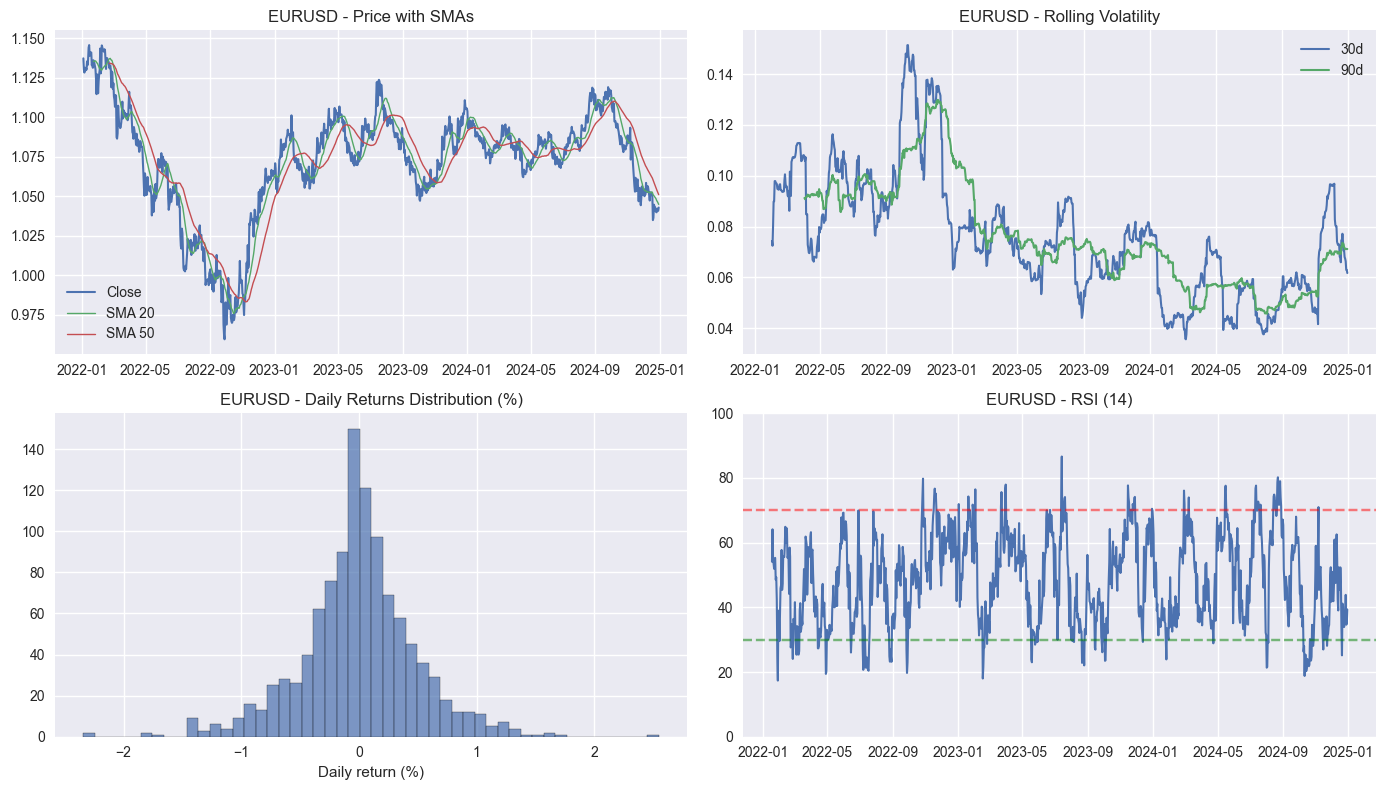

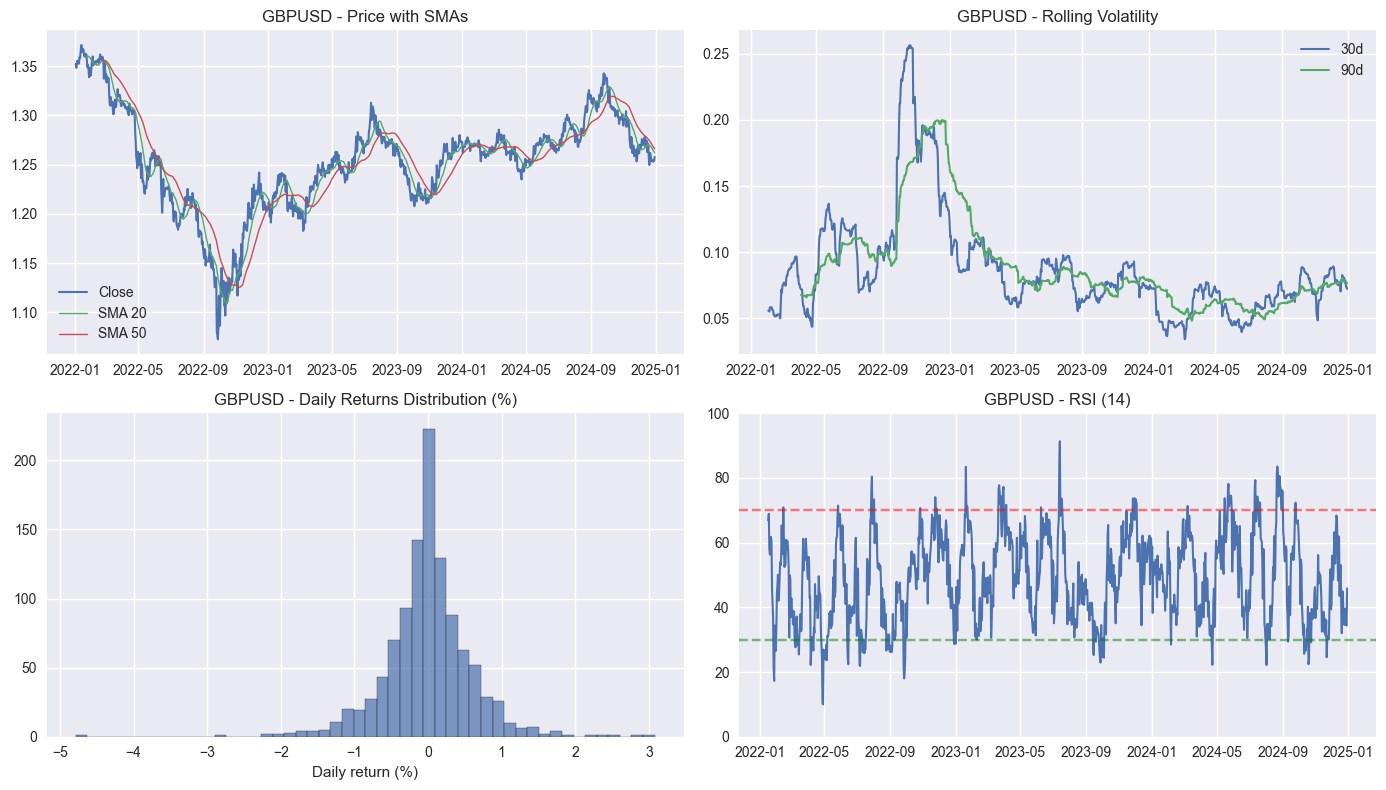

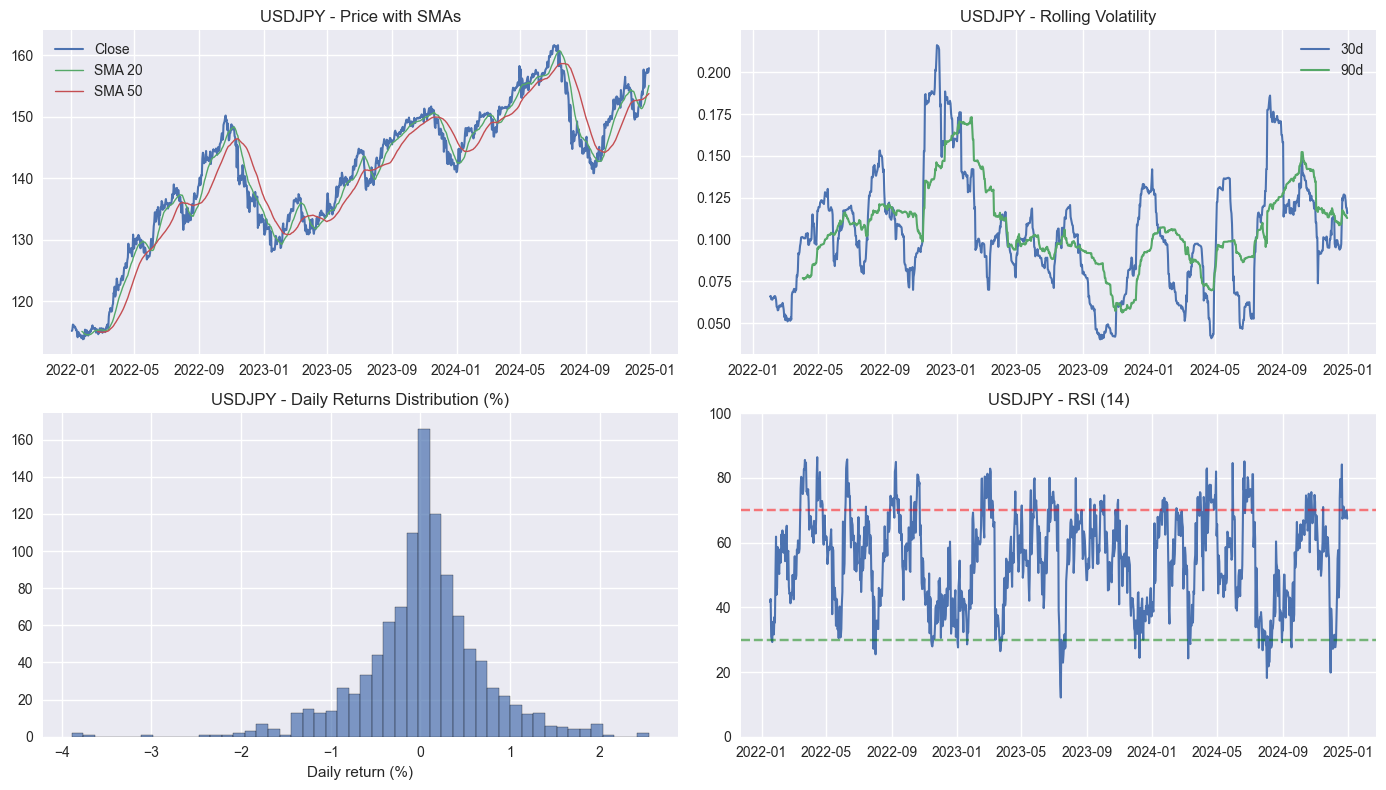

In [10]:
pairs = ["EURUSD", "GBPUSD", "USDJPY"]
for pair in pairs:
    # Create 2x2 subplots for each FX pair
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    # Plot closing price with 20d/50d SMAs
    axes[0, 0].plot(merged.index, merged[f"{pair}_Close"], label="Close", linewidth=1.5)
    axes[0, 0].plot(sma.index, sma[f"{pair}_SMA_20"], label="SMA 20", linewidth=1)
    axes[0, 0].plot(sma.index, sma[f"{pair}_SMA_50"], label="SMA 50", linewidth=1)
    axes[0, 0].set_title(f"{pair} - Price with SMAs")
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Plot rolling volatility (30d & 90d)
    axes[0, 1].plot(volatility.index, volatility[f"{pair}_vol_30d"], label="30d", linewidth=1.5)
    axes[0, 1].plot(volatility.index, volatility[f"{pair}_vol_90d"], label="90d", linewidth=1.5)
    axes[0, 1].set_title(f"{pair} - Rolling Volatility")
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # Plot daily returns distribution (histogram) in percentage terms
    axes[1, 0].hist(returns_pct[f"{pair}_Return"].dropna(), bins=50, alpha=0.7, edgecolor="black")
    axes[1, 0].set_title(f"{pair} - Daily Returns Distribution (%)")
    axes[1, 0].set_xlabel("Daily return (%)")
    axes[1, 0].grid(True)
    
    # Plot RSI (14 days) with overbought/oversold lines
    axes[1, 1].plot(rsi.index, rsi[f"{pair}_RSI_14"], linewidth=1.5)
    axes[1, 1].axhline(y=70, color='r', linestyle='--', alpha=0.5) # Overbought threshold
    axes[1, 1].axhline(y=30, color='g', linestyle='--', alpha=0.5) # Oversold threshold
    axes[1, 1].set_title(f"{pair} - RSI (14)")
    axes[1, 1].set_ylim(0, 100)
    axes[1, 1].grid(True)
    
    plt.tight_layout() # Better subplot spacing
    plt.show()


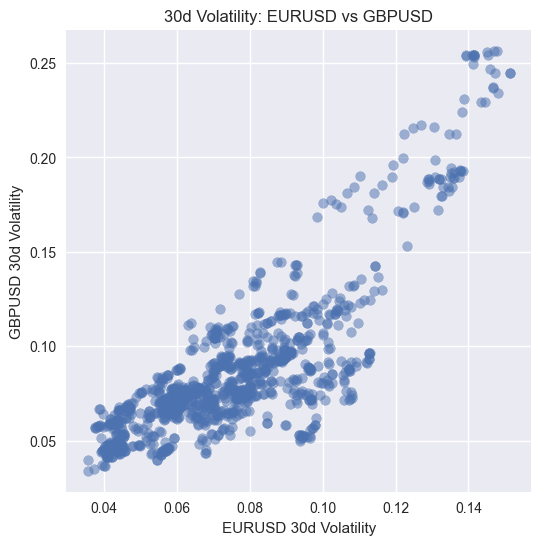

In [11]:
# Scatter plot comparing EURUSD and GBPUSD 30-day volatility
plt.figure(figsize=(6, 6))  # Set plot size
plt.scatter(volatility["EURUSD_vol_30d"], volatility["GBPUSD_vol_30d"], alpha=0.5)  # Plot points
plt.title("30d Volatility: EURUSD vs GBPUSD")  # Add title
plt.xlabel("EURUSD 30d Volatility")  # X-axis label
plt.ylabel("GBPUSD 30d Volatility")  # Y-axis label
plt.grid(True)  # Show grid
plt.show()  # Display plot


## 8. Results Interpretation and Analysis

This section presents a comprehensive interpretation of the analytical results obtained from the technical analysis of the three currency pairs under study. The findings are examined through the lens of price dynamics, volatility characteristics, return distributions, and momentum indicators.

---

### EUR/USD Analysis

#### Price Dynamics and Trend Characteristics

The EUR/USD exchange rate exhibited significant price movements throughout the analysis period (2022-2024). The pair experienced a notable decline during mid-2022, with the exchange rate falling below the psychological parity level of 1.00. This depreciation reflected market concerns regarding European economic conditions and divergent monetary policy stances between the European Central Bank and the Federal Reserve.

A recovery phase commenced in late 2022, with the exchange rate approaching 1.10 by early 2023, indicating a shift in market sentiment and improved confidence in the Euro. The moving average analysis reveals several significant crossover events: a Golden Cross pattern (20-day SMA crossing above 50-day SMA) in late 2022 signaled potential bullish momentum, while Death Cross patterns (20-day SMA crossing below 50-day SMA) in mid-2023 and late 2024 indicated bearish momentum shifts.

#### Volatility Analysis

Volatility measures demonstrate distinct temporal patterns. The peak in 30-day annualized volatility occurred in October 2022, reaching approximately 15%, reflecting heightened market uncertainty around the European energy crisis and aggressive Fed tightening. By mid-2023, volatility normalized to levels around 6-7%, indicating more stable market conditions. The observed volatility clustering pattern—where periods of high volatility are followed by additional high volatility periods—is consistent with established empirical findings in financial econometrics, particularly ARCH/GARCH effects.

#### Return Distribution Characteristics

The daily returns distribution exhibits approximately normal characteristics, centered around zero with most observations falling within the range of -0.5% to +0.5%. Extreme movements (beyond ±2%) occur infrequently but represent significant tail risk events. The distribution appears relatively symmetric, suggesting no strong directional bias in daily returns over the analysis period.

#### Momentum Indicators

The Relative Strength Index (RSI) oscillated frequently between overbought (above 70) and oversold (below 30) levels, indicating active trading conditions. These oscillations create opportunities for both trend-following and mean-reversion trading strategies.

---

### GBP/USD Analysis

#### Price Dynamics and Market Events

The GBP/USD pair experienced one of the most significant price movements observed during the analysis period. In late 2022, the exchange rate declined from approximately 1.35 to below 1.10, representing a substantial depreciation. This movement coincided with UK political instability, economic policy concerns, and US dollar strength, creating a confluence of bearish factors.

Market resilience was demonstrated through a recovery phase in mid-2023, with the exchange rate recovering above 1.25. This recovery illustrates the dynamic nature of currency markets and the potential for mean reversion following extreme movements.

#### Volatility Characteristics

Late 2022 witnessed an exceptional volatility spike, with 30-day annualized volatility exceeding 25%. This level substantially exceeds typical volatility ranges for major currency pairs (typically 5-10%) and reflects the extreme market stress during the UK political and economic crisis. Volatility subsequently normalized to more typical levels (5-10%) in 2023-2024, demonstrating the transitory nature of crisis-induced volatility.

#### Risk Profile

The return distribution for GBP/USD exhibits a wider dispersion compared to EUR/USD, with tails extending to approximately -4% and +2%. This wider distribution reflects the higher inherent volatility of the pair. The distribution displays a slight negative skew, indicating that large negative returns occur more frequently than large positive returns—an important consideration for risk management.

#### Momentum Extremes

RSI readings for GBP/USD were more extreme than those observed for EUR/USD, with values frequently exceeding 80 or dropping below 20. These extreme readings signal very strong momentum in both directions, which may be advantageous for momentum-based trading strategies but presents increased risk for positions established against the prevailing trend.

---

### USD/JPY Analysis

#### Trend Characteristics

USD/JPY exhibited one of the clearest and most sustained trends observed during the analysis period. The exchange rate appreciated from approximately 115 in early 2022 to nearly 158 by late 2024, representing a cumulative appreciation of approximately 37% over three years.

#### Fundamental Drivers

This trend was driven by fundamental economic factors, specifically divergent monetary policies. The US Federal Reserve implemented aggressive interest rate increases, while the Bank of Japan maintained near-zero interest rates. This substantial interest rate differential created strong fundamental support for US dollar appreciation relative to the Japanese yen.

#### Technical Confirmation

The price consistently remained above both moving averages throughout the uptrend, with multiple Golden Cross patterns confirming bullish momentum. Even during correction phases (notably in mid-2023 and early 2024), the underlying trend remained intact, demonstrating the strength of the fundamental drivers.

#### Volatility and Risk

USD/JPY exhibited consistently high volatility throughout the analysis period, with peaks reaching approximately 22% (30-day annualized). While GBP/USD recorded the absolute highest volatility spike (approximately 25% in late 2022), USD/JPY demonstrated the highest sustained volatility levels over the entire period, reflecting the pair's sensitivity to central bank policy changes and intervention activities. The Bank of Japan's intervention activities can create significant short-term volatility spikes.

#### Return Distribution

The return distribution displays a slight positive bias, consistent with the overall uptrend. However, the left tail extends further (-3.5%) than the right tail (+2.5%), indicating that correction phases can be particularly severe despite the overall upward trend.

#### Momentum Persistence

The RSI frequently entered overbought territory (above 70) during strong upward moves, particularly in early 2022, late 2022, late 2023, and mid-2024. In strong trending markets, RSI can remain in overbought territory for extended periods, requiring contextual interpretation rather than mechanical application of overbought signals.

---

### Cross-Pair Volatility Correlation Analysis

#### Correlation Structure

The scatter plot analysis comparing EUR/USD and GBP/USD 30-day volatilities reveals a positive correlation structure. When EUR/USD volatility increases, GBP/USD volatility tends to increase concurrently, indicating shared risk factors affecting both European currency pairs.

#### Economic Rationale

This correlation is economically intuitive, as both pairs represent European currencies against the US dollar. Common risk drivers include:
- US dollar strength or weakness
- European economic conditions
- Global risk sentiment
- Central bank policy changes

#### Portfolio Implications

The correlation is not perfect, as evidenced by the dispersion of observations at higher volatility levels. This imperfect correlation suggests that some diversification benefits remain available, though limited, when holding positions in both European pairs simultaneously.

#### Regime-Dependent Relationships

At low volatility levels (bottom-left region of the scatter plot), the relationship appears tighter and more predictable. As volatility increases (moving toward the top-right region), the relationship becomes more variable, suggesting that during extreme market stress, each pair may exhibit unique drivers and characteristics.

---

### Summary and Conclusions

#### Comparative Risk Assessment

The analysis reveals distinct risk profiles across the three currency pairs:

1. **USD/JPY**: Highest sustained volatility (~11.58% current 30-day annualized), reflecting sensitivity to monetary policy divergence and central bank interventions. While GBP/USD recorded the absolute peak volatility (25% in late 2022), USD/JPY exhibited the most consistently elevated volatility levels throughout the entire period.
2. **GBP/USD**: Moderate-high volatility (~7.22% current 30-day annualized), influenced by political and economic factors. This pair experienced the most extreme single volatility spike (approximately 25% in late 2022) during the UK political crisis.
3. **EUR/USD**: Lowest volatility (~6.17% current 30-day annualized), exhibiting more stable characteristics

#### Trading Strategy Implications

The distinct characteristics of each pair suggest different suitability for various trading approaches:

- **Trend-following strategies**: USD/JPY offers clear directional trends driven by fundamental factors
- **Range-trading strategies**: EUR/USD provides more stable, range-bound conditions
- **Volatility-based strategies**: GBP/USD exhibits periods of elevated volatility suitable for volatility trading

#### Risk Management Considerations

The analysis highlights several important risk management principles:

1. **Volatility-based position sizing**: Volatility levels provide critical information for appropriate position sizing
2. **Context-dependent indicator interpretation**: RSI extremes require contextual analysis, particularly in strong trending markets
3. **Fundamental awareness**: Monetary policy and political events serve as primary drivers of currency movements
4. **Correlation awareness**: European pairs exhibit positive correlation, limiting diversification benefits

#### Methodological Observations

The sequential 5-day rolling mean imputation methodology successfully preserved trend characteristics while avoiding artificial price plateaus. The technical indicators (moving averages, RSI, volatility measures) provided consistent and interpretable signals throughout the analysis period.
